<a href="https://colab.research.google.com/github/joseguilhermemarinho/big_data_proj/blob/main/codigo/notebooks/AV2_gold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Camada Gold - Análises SPPO Rio de Janeiro

Realizando as análises exploratórias da camada gold a partir dos dados limpos da camada silva.

## Configurações e Identidade Visual
Nesta etapa, preparamos o ambiente de trabalho definindo paletas de cores institucionais e configurações de plotagem. Padronizar a visualização é fundamental para que o tom da análise seja profissional e facilite a leitura de mapas e gráficos complexos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
import warnings
import pyarrow.parquet as pq
import os


warnings.filterwarnings('ignore')

AZUL       = '#1A6FBF'
LARANJA    = '#F28C28'
VERDE      = '#2ECC71'
VERMELHO   = '#E74C3C'
AMARELO    = '#F1C40F'
CINZA_BG   = '#F4F6F9'
CINZA_TEXTO= '#2C3E50'

plt.rcParams.update({
    'figure.facecolor': CINZA_BG,
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#CCCCCC',
    'axes.labelcolor':  CINZA_TEXTO,
    'text.color':       CINZA_TEXTO,
    'xtick.color':      CINZA_TEXTO,
    'ytick.color':      CINZA_TEXTO,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
})

os.makedirs('./gold', exist_ok=True)

## Carregamento dos Dados (Camada Silver)
Importamos os dados validados da camada Silver. O uso do formato Parquet com PyArrow garante eficiência no processamento de grandes volumes de GPS, mantendo a integridade dos tipos de dados, especialmente os timestamps.

In [ ]:
table = pq.read_table('sppo_silver.parquet')
df = table.to_pandas(timestamp_as_object=False)

for col in ['datahora', 'datahoraenvio', 'datahoraservidor']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')

df['data'] = df['datahora'].dt.normalize()
df['hora']   = df['datahora'].dt.hour
df['linha']  = df['linha'].astype(str).str.strip()

print(f'{len(df):,} registros carregados')
print(f'   Tipos: {df[["datahora","hora","velocidade"]].dtypes.to_dict()}')
df.head(3)

508,468 registros carregados
   Tipos: {'datahora': datetime64[ms, UTC], 'hora': dtype('int32'), 'velocidade': dtype('int64')}


,ordem,latitude,longitude,datahora,velocidade,linha,datahoraenvio,datahoraservidor,momento_extracao,data,hora,minuto,dia_semana,latencia_envio_s,latencia_servidor_s
0,D33207,-22.90246,-43.56223,2026-06-02 11:21:25+00:00,26,822,2026-06-02 11:21:37+00:00,2026-06-02 11:21:42+00:00,2026-06-02 09:21:55,2026-06-02 00:00:00+00:00,11,21,Tuesday,12.0,5.0
1,D33318,-22.85487,-43.39731,2026-06-02 11:21:27+00:00,39,764,2026-06-02 11:21:37+00:00,2026-06-02 11:21:42+00:00,2026-06-02 09:21:55,2026-06-02 00:00:00+00:00,11,21,Tuesday,10.0,5.0
2,D33307,-22.87964,-43.46424,2026-06-02 11:21:27+00:00,24,741,2026-06-02 11:21:37+00:00,2026-06-02 11:21:42+00:00,2026-06-02 09:21:55,2026-06-02 00:00:00+00:00,11,21,Tuesday,10.0,5.0


## Refino e Qualidade da Informação
Mesmo na camada Gold, realizamos um último filtro de segurança para remover coordenadas ruidosas (como latitude zero) e garantir que estamos analisando apenas registros com GPS e identificação de linha íntegros.

In [ ]:
df = df[df['datahora'].dt.year > 2020]
df = df[(df['latitude'] != 0) & (df['longitude'] != 0)]
df['velocidade'] = pd.to_numeric(df['velocidade'], errors='coerce')
df = df.dropna(subset=['velocidade', 'linha', 'ordem'])

print(f'Registros válidos: {len(df):,}')

Registros válidos: 508,468


## Categorização do Movimento
Transformamos a velocidade bruta em categorias semânticas. Esta simplificação é vital para que gestores identifiquem rapidamente se a frota está em regime de fluidez ou retida em congestionamentos.

In [ ]:
def classificar_movimento(v):
    if v == 0: return 'Parado/Garagem'
    elif v <= 15: return 'Lentidão/Trânsito'
    else: return 'Fluído'

df['status_movimento'] = df['velocidade'].apply(classificar_movimento)
df['status_movimento'] = pd.Categorical(df['status_movimento'], categories=['Parado/Garagem', 'Lentidão/Trânsito', 'Fluído'])

display(df[['velocidade', 'status_movimento']].head())

,velocidade,status_movimento
0,26,Fluído
1,39,Fluído
2,24,Fluído
3,22,Fluído
4,33,Fluído


## Segmentação: Comercial vs. Operação Técnica
Para uma análise fiel da mobilidade, separamos o que é serviço ao passageiro do que são movimentações internas (manutenção/treino). Focaremos agora apenas no `df_operacao`.

In [ ]:
df['tipo_linha'] = np.where(
    df['linha'].str.contains('SN|MANUTENCAO|TREINO|VISTORIA|SP|FORA DE OP', na=False),
    'tecnica',
    'comercial'
)

df[['linha', 'tipo_linha']].drop_duplicates().head(50)

,linha,tipo_linha
0,822,comercial
1,764,comercial
2,741,comercial
3,746,comercial
4,756,comercial
5,812,comercial
6,798,comercial
7,926,comercial
9,SV391,comercial
10,757,comercial


In [ ]:
df_operacao = df[df['tipo_linha'] == 'comercial'].copy()

print(f'Registros operacionais: {len(df_operacao):,}')

Registros operacionais: 493,017


## Snapshot da Operação
Aqui quantificamos o fôlego da cidade: quantos ônibus estão na rua agora? Qual a velocidade real do sistema? O percentual de ônibus parados é um indicador crítico de eficiência ou de gargalos em terminais.

In [ ]:
onibus_ativos = df_operacao['ordem'].nunique()
linhas_ativas = df_operacao['linha'].nunique()
vel_media     = df_operacao['velocidade'].mean()
pct_parados   = (df_operacao['status_movimento'] == 'Parado/Garagem').mean() * 100

print('SNAPSHOT DA OPERAÇÃO')
print(f'Ônibus ativos: {onibus_ativos}')
print(f'Linhas ativas: {linhas_ativas}')
print(f'Velocidade média: {vel_media:.2f} km/h')
print(f'% em Garagem/Parado: {pct_parados:.2f}%')

SNAPSHOT DA OPERAÇÃO
Ônibus ativos: 3836
Linhas ativas: 370
Velocidade média: 15.85 km/h
% em Garagem/Parado: 28.84%


## Rankings de Atividade e Performance
Identificamos as linhas que carregam o sistema (maior volume de frota) e aquelas que sofrem com a baixa velocidade média, auxiliando na priorização de intervenções viárias.

## Monitoramento Temporal (Log de Métricas)
Data Science não é apenas uma foto, é um filme. Aqui criamos um mecanismo para salvar os snapshots atuais, permitindo futuras análises de séries temporais sobre a evolução do trânsito.

In [ ]:
from datetime import datetime

resumo = pd.DataFrame([{
    'timestamp': datetime.utcnow(),
    'onibus_ativos': onibus_ativos,
    'linhas_ativas': linhas_ativas,
    'vel_media': vel_media,
    'vel_mediana': vel_mediana,
    'pct_parados': pct_parados
}])

resumo

,timestamp,onibus_ativos,linhas_ativas,vel_media,vel_mediana,pct_parados
0,2026-06-04 22:44:15.079303,3836,370,15.846046,13.0,28.841602


In [ ]:
caminho = './gold/resumo_metricas.csv'

if not os.path.exists(caminho):
    resumo.to_csv(caminho, index=False)
    print('Arquivo criado!')
else:
    resumo.to_csv(caminho, mode='a', header=False, index=False)
    print('Snapshot adicionado!')

Snapshot adicionado!


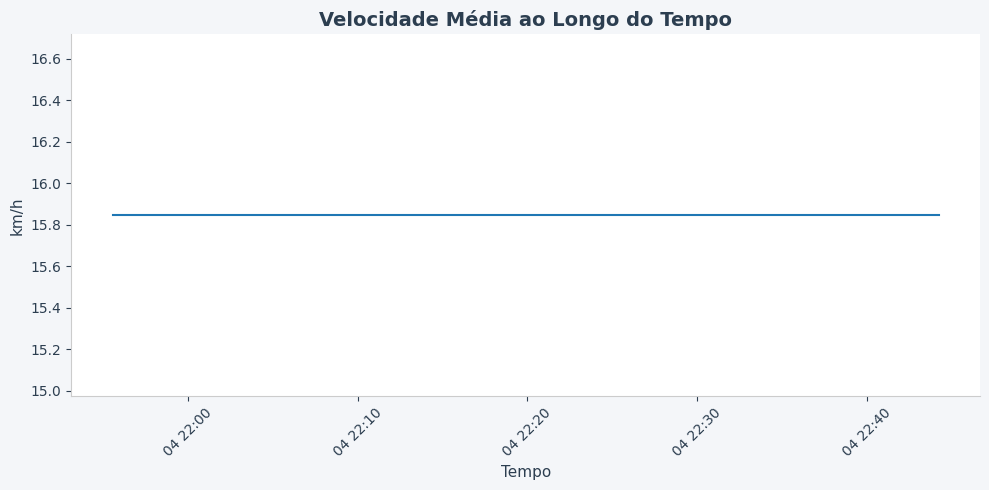

In [ ]:
df_resumo = pd.read_csv(caminho, parse_dates=['timestamp'])

plt.figure(figsize=(10,5))

plt.plot(df_resumo['timestamp'], df_resumo['vel_media'])
plt.title('Velocidade Média ao Longo do Tempo')
plt.xlabel('Tempo')
plt.ylabel('km/h')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

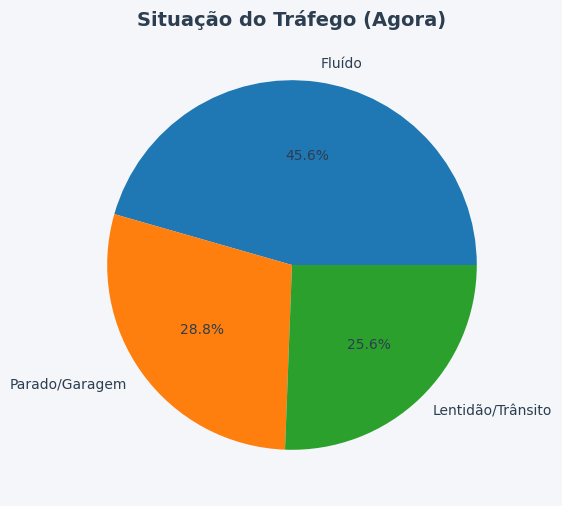

In [ ]:
status_dist = df_operacao['status_movimento'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))

plt.pie(
    status_dist,
    labels=status_dist.index,
    autopct='%1.1f%%'
)

plt.title('Situação do Tráfego (Agora)')
plt.show()

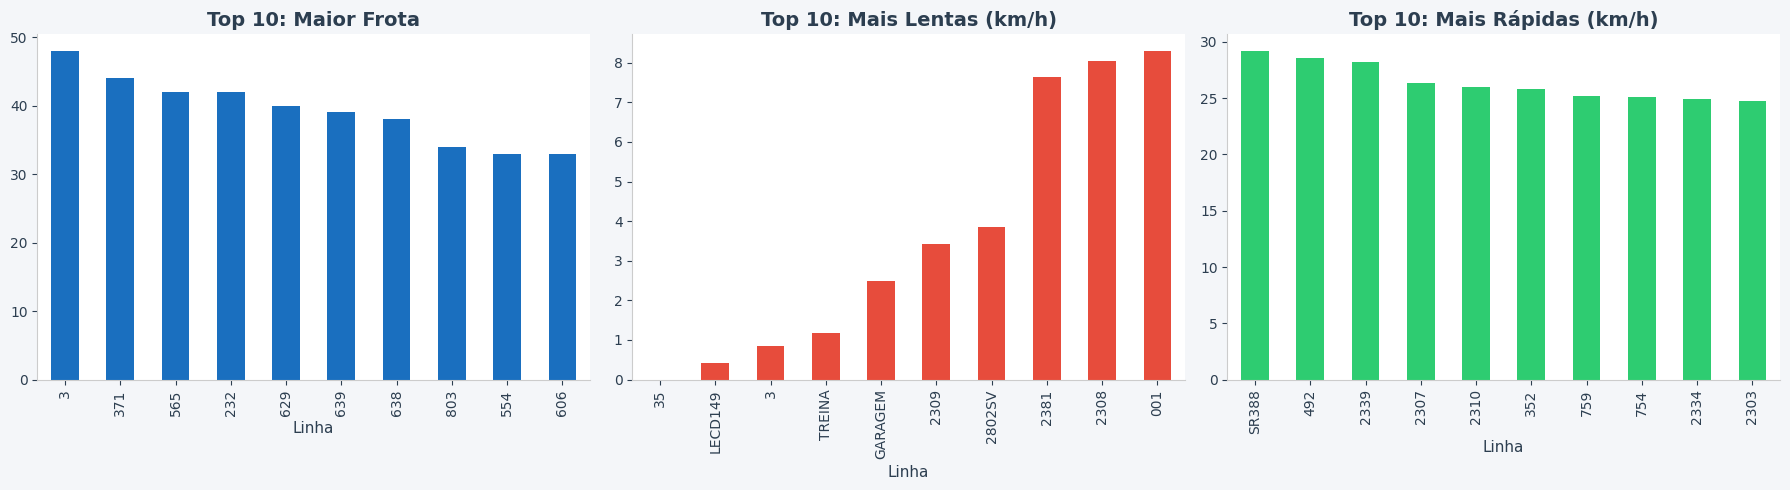

In [ ]:
top_frota = df_operacao.groupby('linha')['ordem'].nunique().sort_values(ascending=False).head(10)
ranking_lentas = df_operacao.groupby('linha')['velocidade'].mean().sort_values().head(10)
ranking_rapidas = df_operacao.groupby('linha')['velocidade'].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_frota.plot(kind='bar', color=AZUL, ax=axes[0], title='Top 10: Maior Frota')
ranking_lentas.plot(kind='bar', color=VERMELHO, ax=axes[1], title='Top 10: Mais Lentas (km/h)')
ranking_rapidas.plot(kind='bar', color=VERDE, ax=axes[2], title='Top 10: Mais Rápidas (km/h)')

for ax in axes: ax.set_xlabel('Linha')
plt.tight_layout()
plt.show()

## Distribuição Geográfica: Cobertura e Capilaridade

Este mapa de dispersão simples nos permite visualizar a 'mancha' de atendimento do sistema. Em uma cidade com a geografia complexa do Rio de Janeiro, identificar áreas com alta densidade de pontos vs. áreas de vazio operacional é o primeiro passo para planejar a expansão da rede ou identificar zonas de sombra no GPS.

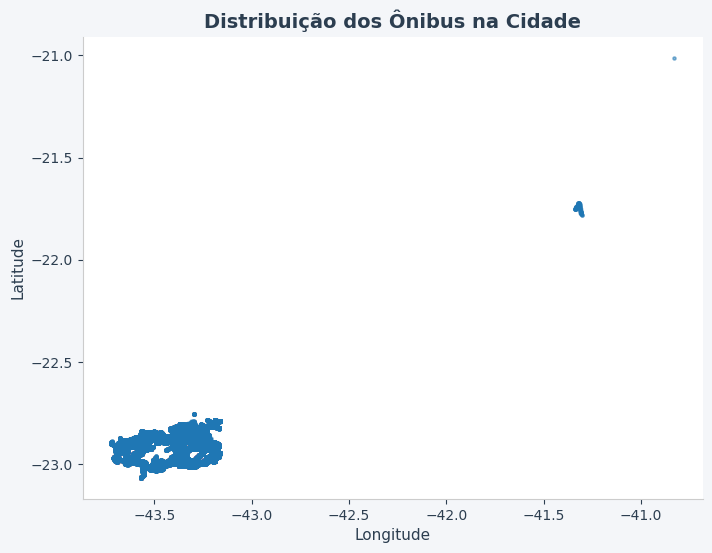

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_operacao['longitude'],
    df_operacao['latitude'],
    alpha=0.3,
    s=5
)

plt.title('Distribuição dos Ônibus na Cidade')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

## Curva de Oferta: Disponibilidade para o Cidadão

Abaixo, analisamos a volumetria de veículos únicos por hora. Este gráfico é o coração da operação: ele revela se a frota planejada está de fato na rua nos horários de pico. Quedas acentuadas nesta curva indicam falta de oferta, resultando em pontos de ônibus superlotados e maior tempo de espera para o passageiro.

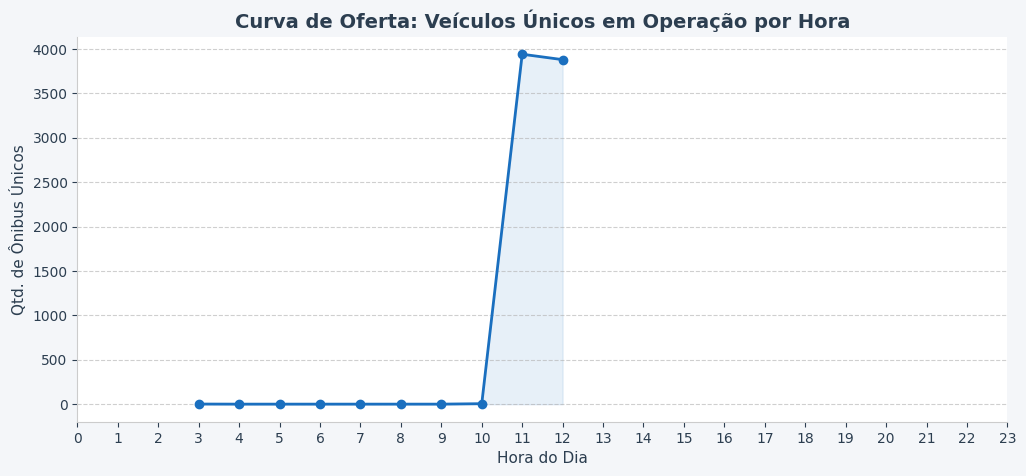

In [ ]:
oferta_hora = df.groupby('hora')['ordem'].nunique()

plt.figure(figsize=(12, 5))
plt.plot(oferta_hora.index, oferta_hora.values, marker='o', color=AZUL, linewidth=2)
plt.fill_between(oferta_hora.index, oferta_hora.values, alpha=0.1, color=AZUL)

plt.title('Curva de Oferta: Veículos Únicos em Operação por Hora')
plt.xlabel('Hora do Dia')
plt.ylabel('Qtd. de Ônibus Únicos')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.xticks(range(0, 24))
plt.show()

##Mapa de Calor: Identificação de Gargalos Urbanos

Focamos agora exclusivamente nos ônibus que estão 'se arrastando' (entre 1 e 15 km/h). Este mapa não mostra onde os ônibus estão, mas sim **onde o trânsito está travando o transporte público**. Áreas com alta densidade de calor são candidatos críticos para a implementação de faixas exclusivas ou BRS.

In [ ]:
import folium
from folium.plugins import HeatMap

df_gargalos = df[(df['velocidade'] > 0) & (df['velocidade'] <= 15)]

mapa_rio = folium.Map(location=[-22.9068, -43.1729], zoom_start=11, tiles='cartodbpositron')

heat_data = [[row['latitude'], row['longitude']] for index, row in df_gargalos.sample(n=min(10000, len(df_gargalos))).iterrows()]

HeatMap(heat_data, radius=10, blur=15, gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'}).add_to(mapa_rio)

display(mapa_rio)

## Eficiência da Frota: O Custo da Imobilidade

Este gráfico de rosca quantifica a saúde da operação. Uma fatia muito grande de 'Lentidão' representa desperdício de combustível, aumento de emissões e ineficiência operacional. O ideal é que a fatia 'Fluído' domine durante o entrepico.

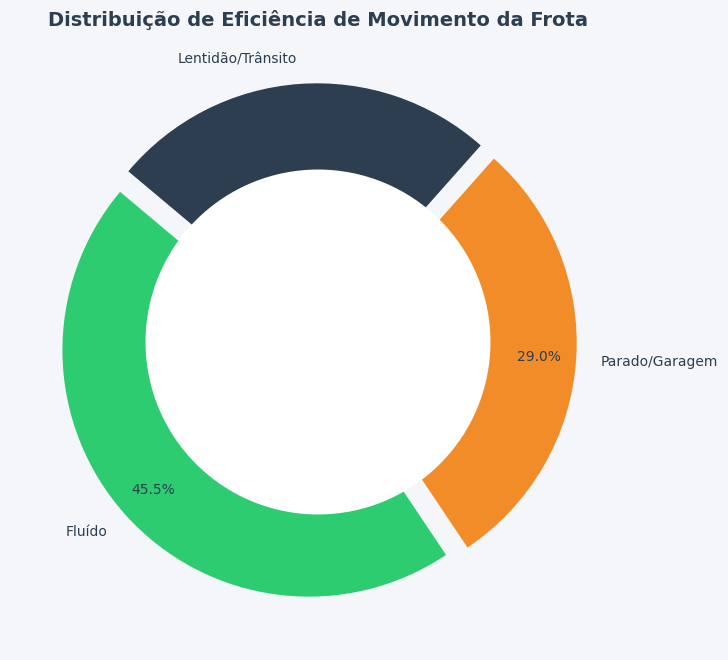

In [ ]:
counts = df['status_movimento'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=[VERDE, LARANJA, CINZA_TEXTO],
        startangle=140, pctdistance=0.85, explode=(0.05, 0.05, 0.05))

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribuição de Eficiência de Movimento da Frota')
plt.show()

## Desempenho por Linha: Variabilidade e Confiabilidade

Ao analisarmos as 10 linhas mais ativas através de boxplots, buscamos entender a constância do serviço. Boxplots curtos indicam uma velocidade previsível; boxplots longos ou com muitos outliers indicam uma operação instável, onde o passageiro enfrenta alta incerteza sobre o tempo de viagem.

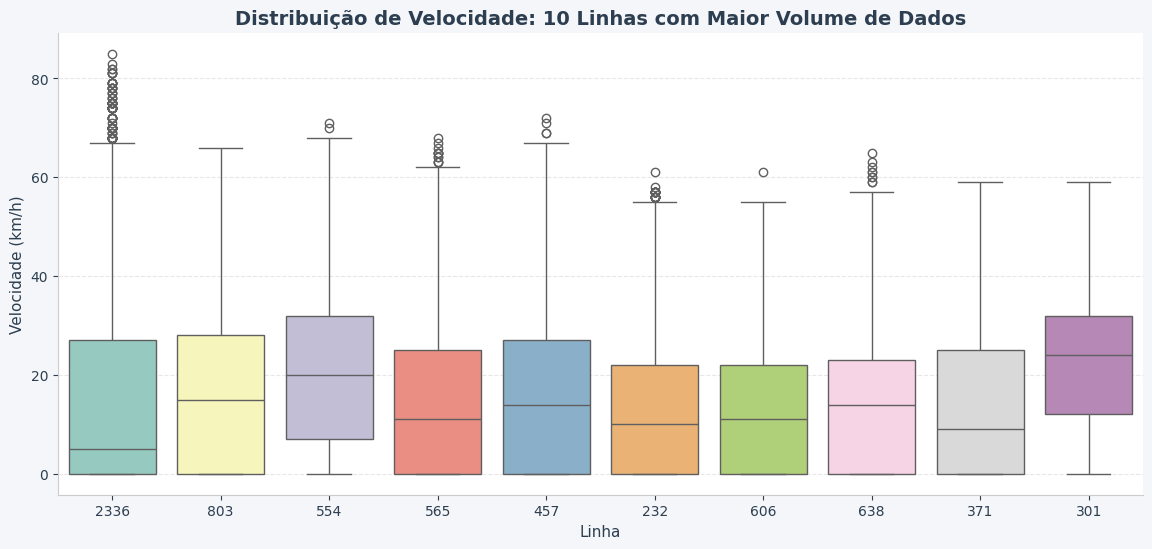

In [ ]:
top_10_linhas = df['linha'].value_counts().head(10).index
df_top_perf = df[df['linha'].isin(top_10_linhas)]

plt.figure(figsize=(14, 6))
sns.boxplot(x='linha', y='velocidade', data=df_top_perf, palette='Set3')

plt.title('Distribuição de Velocidade: 10 Linhas com Maior Volume de Dados')
plt.ylabel('Velocidade (km/h)')
plt.xlabel('Linha')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## Persistência dos Dados

Consolidamos as novas métricas em um arquivo otimizado para dashboards de monitoramento em tempo real.

In [ ]:
os.makedirs('dados', exist_ok=True)
caminho_gold = 'dados/sppo_amostra_gold.parquet'

df.to_csv('dados_gold.csv', index=False)
df.to_parquet(caminho_gold, compression='snappy', index=False)
print(f'Dataset Gold salvo com sucesso em: {caminho_gold}')

Dataset Gold salvo com sucesso em: dados/sppo_amostra_gold.parquet


## Dashboard Interativo: Monitoramento em Tempo Real

Para facilitar o monitoramento contínuo e a tomada de decisões ágeis, criamos um dashboard interativo. Esta ferramenta permite visualizar a localização e o status dos ônibus em tempo real, com a capacidade de filtrar por linha específica ou tipo de movimento (fluído, lentidão/trânsito, parado/garagem).

Este mapa não só exibe a posição atual da frota, mas também oferece um *snapshot* visual da eficiência operacional, destacando onde os veículos estão se movendo livremente, enfrentando lentidão ou estão parados. É uma visão dinâmica para compreender a performance da mobilidade urbana e identificar rapidamente áreas que demandam atenção imediata.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import folium

df_dash = df.copy()

linhas_disponiveis = ['Todas'] + sorted(df_dash['linha'].dropna().unique().tolist())
dropdown_linha = widgets.Dropdown(
    options=linhas_disponiveis,
    value='Todas',
    description='Filtrar Linha:',
    style={'description_width': 'initial'}
)

status_disponiveis = ['Todos', 'Fluído', 'Lentidão/Trânsito', 'Parado/Garagem']
dropdown_status = widgets.Dropdown(
    options=status_disponiveis,
    value='Todos',
    description='Status:',
    style={'description_width': 'initial'}
)

output = widgets.Output()

def atualizar_dashboard(change=None):
    with output:
        clear_output(wait=True)

        df_filtrado = df_dash.copy()
        if dropdown_linha.value != 'Todas':
            df_filtrado = df_filtrado[df_filtrado['linha'] == dropdown_linha.value]
        if dropdown_status.value != 'Todos':
            df_filtrado = df_filtrado[df_filtrado['status_movimento'] == dropdown_status.value]

        total_veiculos = df_filtrado['ordem'].nunique()
        vel_media = df_filtrado['velocidade'].mean() if total_veiculos > 0 else 0

        print("=" * 60)
        print(f"PAINEL DE MOBILIDADE - RIO DE JANEIRO")
        print(f"Ônibus Ativos: {total_veiculos} | Velocidade Média: {vel_media:.1f} km/h")
        print("=" * 60)

        if total_veiculos == 0:
            print("Nenhum veículo encontrado com estes filtros.")
            return

        mapa = folium.Map(location=[-22.9068, -43.1729], zoom_start=11)

        for _, row in df_filtrado.head(500).iterrows():
            if row['status_movimento'] == 'Fluído':
                cor = '#2ECC71'
            elif row['status_movimento'] == 'Lentidão/Trânsito':
                cor = '#F1C40F'
            else:
                cor = '#E74C3C'

            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=5,
                color=cor,
                fill=True,
                fill_opacity=0.7,
                popup=f"Linha: {row['linha']} | Vel: {row['velocidade']} km/h"
            ).add_to(mapa)

        display(mapa)

dropdown_linha.observe(atualizar_dashboard, names='value')
dropdown_status.observe(atualizar_dashboard, names='value')

painel_filtros = widgets.HBox([dropdown_linha, dropdown_status])
display(painel_filtros)
display(output)

atualizar_dashboard()

Output()